# Image Color Quantization with SOM

Load an image, quantize its colors using `SomVQ`, display before/after.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from dbgsom import SomVQ

img = Image.open("IMG_9418.jpg").convert("RGB").resize((750, 500))
arr = np.array(img) / 255.0  # (H, W, 3) float32
pixels = arr.reshape(-1, 3)  # (H*W, 3)
print(f"{pixels.shape[0]:,} pixels, image size {img.size}")

375,000 pixels, image size (750, 500)


In [15]:
lambda_ = 20000


from sklearn.cluster import k_means


def estimate_n_neurons(X, lambda_, seed=42):
    """Estimate equilibrium neuron count K_eq before training.

    K_eq ≈ (3/2) * n * QE_bar / (lambda * ||std(X)||)
    QE_bar estimated with 4 random prototype neurons (upper bound).
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    gt = lambda_ * np.linalg.norm(X.std(axis=0))
    centroids = X[rng.choice(n, size=4, replace=False)]
    centroids = k_means(X, 4)[0]
    qe_mean = np.linalg.norm(X[:, None] - centroids[None], axis=2).min(axis=1).mean()
    return int(np.round(1.5 * n * qe_mean / gt))


print(f"Estimated neurons: {estimate_n_neurons(pixels, lambda_=lambda_)}")

Estimated neurons: 7


In [16]:
som = SomVQ(
    lambda_=lambda_,
    # sigma_start=3,
    # sigma_end=1,
    # n_iter=1000,
    random_state=42,
    verbose=True,
    pointer_search="all",
    winner_stability_threshold=0.01,
)
som.fit(pixels)
print(f"{len(som.neurons_)} colors in quantized palette")

 10%|█         | 52/500 [00:02<00:18, 24.30 epochs/s]


8 colors in quantized palette


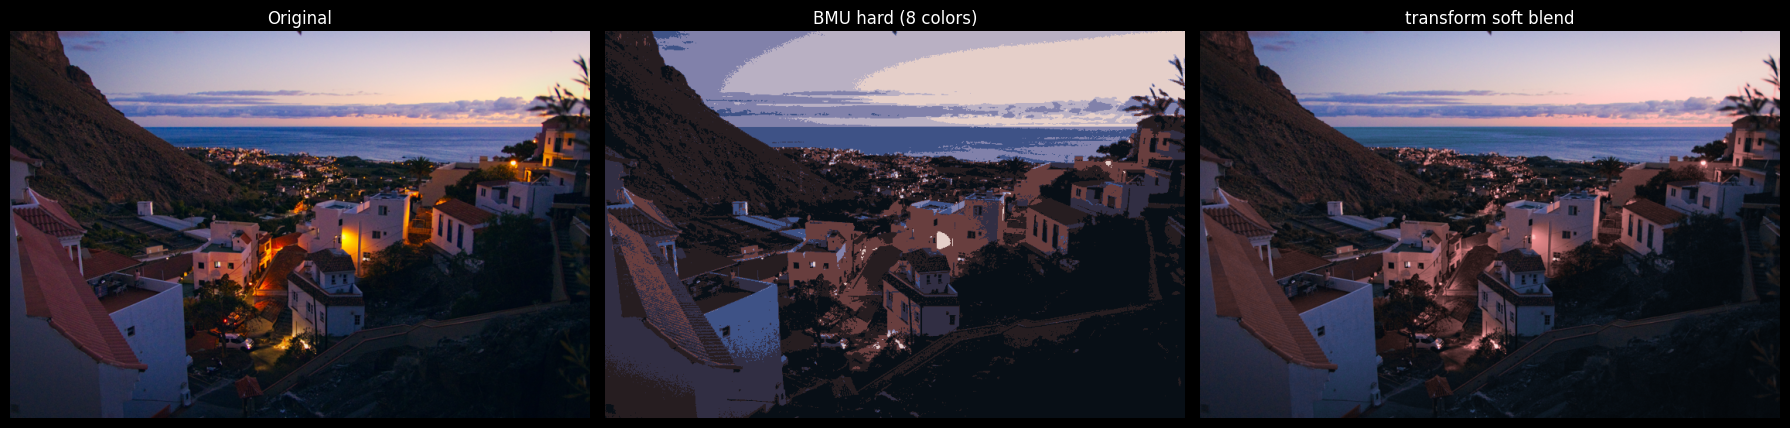

In [17]:
hard = som.weights_[som.predict(pixels)]
soft = som.transform(pixels) @ som.weights_  # sparse linear combo of prototypes

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, data, title in zip(
    axes,
    [arr, hard, soft],
    ["Original", f"BMU hard ({len(som.neurons_)} colors)", "transform soft blend"],
):
    ax.imshow(np.clip(data.reshape(arr.shape), 0, 1))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()